# Metals Model Comparison — Variant Selection

**Instruments:** `gc1s` (XGB precious pool) | `si1s` (XGB individual) | `pl1s` (Logistic individual) | `hg1s` (RF individual)

**Protocol**
- Phase 1: CPCV (n=6, k=2, embargo=0.01) on **TRAIN only**. Locked pick committed to `locked_picks.csv` before test is read.
- Phase 2: Single-shot OOS on **sealed test** (date > 2021-10-20). Scored **once**.
- Non-locked OOS is diagnostic transparency — it played no role in variant selection.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import warnings; warnings.filterwarnings('ignore')
from IPython.display import Image, display

BASE = Path('outputs/model_comparison/metals')

def show(path, width=950):
    p = Path(path)
    if p.exists(): display(Image(str(p), width=width))

def load(path):
    p = Path(path)
    return pd.read_csv(p) if p.exists() else pd.DataFrame()

cpcv_df   = load(BASE / 'cpcv_results.csv')
locked_df = load(BASE / 'locked_picks.csv')
oos_df    = load(BASE / 'oos_results.csv')
locked_picks = locked_df.set_index('inst')['locked_variant'].to_dict() if not locked_df.empty else {}
print('Locked picks:', locked_picks)

Locked picks: {'gc1s': 'reduced', 'si1s': 'reduced', 'pl1s': 'reduced_plus', 'hg1s': 'reduced'}


## Variant Definitions

| Instrument | Family / Pool | Full | Pruned | Reduced |
|---|---|---|---|---|
| `gc1s` | XGB / precious pool | all 103 pool features | C2\_f1 + C9\_f11\_lowfreq\_macro + C3\_f2 | PC1+PC2 of C2\_f1, PC1+PC2 of C3\_f2 + 3 raw |
| `si1s` | XGB / individual | all 101 features | C13\_f1 + C2\_f11 + C15\_f2 | 6 raw (f1\_mr\_score\_20, f11\_move\_vix\_ratio, f2\_vol\_60, f4\_pc3, f2\_ret\_skew\_60, f11\_dxy\_z) |
| `pl1s` | Logistic / individual | all 100 features | C3\_hmm\_vol + C5\_f11 + C4\_f2 | **reduced\_regime**: PC1+PC2 of C3\_hmm\_vol only (3 members) |
| | | | | **reduced\_plus**: above + PC1+PC2 of C5\_f11 + PC1+PC2 of C4\_f2 + 2 raw (f5\_sign\_agree\_mr, f1\_mr\_score\_10) |
| `hg1s` | RF / individual | all 101 features | C15\_f2 + F5\_signal + C1\_f1 | 5 raw (f5\_signal, f2\_ret\_kurt\_60, f1\_mr\_score\_40, f2\_vol\_ratio\_20\_60, f2\_vol\_of\_vol\_20) |

**pl1s key comparison:** `reduced_regime` is the HMM/vol-regime-only baseline. `reduced_plus` tests whether mean-reversion (F5, F11, F4) features add over that baseline.

**Simplicity ordering** (1SE rule picks leftmost within threshold):
- gc1s/si1s/hg1s: `reduced` < `pruned` < `full`
- pl1s: `reduced_regime` < `reduced_plus` < `pruned` < `full`

---
## Phase 1 — CPCV Variant Scoring (TRAIN only)

CPCV n=6, k=2, embargo=0.01 → 15 test paths. Purge + embargo prevents label-window leakage.
Lock rule: simplest variant with mean AUC ≥ full\_mean − full\_SE.

In [2]:
if not cpcv_df.empty:
    SIMP_ORDER = {
        'gc1s':  {'reduced': 0, 'pruned': 1, 'full': 2},
        'si1s':  {'reduced': 0, 'pruned': 1, 'full': 2},
        'pl1s':  {'reduced_regime': 0, 'reduced_plus': 1, 'pruned': 2, 'full': 3},
        'hg1s':  {'reduced': 0, 'pruned': 1, 'full': 2},
    }
    def _hl(row):
        locked = locked_picks.get(row['inst'], '')
        return ['background-color: #C8E6C9' if row['variant'] == locked else '' for _ in row]
    def _sort_key(r):
        inst = r['inst']
        inst_order = ['gc1s', 'si1s', 'pl1s', 'hg1s']
        io = inst_order.index(inst) if inst in inst_order else 99
        vo = SIMP_ORDER.get(inst, {}).get(r['variant'], 99)
        return (io, vo)
    ordered = cpcv_df.copy()
    ordered['_s'] = ordered.apply(_sort_key, axis=1)
    ordered = ordered.sort_values('_s').drop(columns='_s')
    fmt = {'auc_mean':'{:.4f}','auc_std':'{:.4f}','auc_se':'{:.4f}','logloss':'{:.4f}','brier':'{:.4f}'}
    display(
        ordered[['inst','variant','auc_mean','auc_std','auc_se','logloss','brier','n_paths']]
        .style.format(fmt).apply(_hl, axis=1)
        .set_caption('Phase 1 CPCV — all variants (green = locked per 1SE rule)')
    )

,inst,variant,auc_mean,auc_std,auc_se,logloss,brier,n_paths
2,gc1s,reduced,0.6311,0.1420,0.0367,0.6835,0.2450,15
1,gc1s,pruned,0.4277,0.0975,0.0252,0.6903,0.2486,15
0,gc1s,full,0.5404,0.1007,0.0260,0.7060,0.2558,15
5,si1s,reduced,0.5867,0.0690,0.0178,0.6902,0.2484,15
4,si1s,pruned,0.5339,0.0707,0.0183,0.6934,0.2501,15
3,si1s,full,0.5099,0.0758,0.0196,0.6927,0.2497,15
8,pl1s,reduced_regime,0.5163,0.0441,0.0114,0.6905,0.2480,15
9,pl1s,reduced_plus,0.6406,0.0706,0.0182,0.6550,0.2317,15
7,pl1s,pruned,0.6293,0.0695,0.0179,0.7104,0.2416,15
6,pl1s,full,0.6006,0.0806,0.0208,0.7234,0.2535,15


### GC1S — XGB / precious pool | NO SIGNAL — exploratory

gc1s has only 127 pool events. High CPCV fold variance (std ≈ 0.10–0.14). **No confirmed signal.**
Locked to `reduced` (PC1+PC2 of C2_f1 and C3_f2 + 3 raw) by 1SE rule, but the large dev→OOS gap (+0.18) reflects in-sample overfitting on a thin pool slice. All results are exploratory.

,variant,auc_mean,auc_std,auc_se,logloss,brier,n_paths
0,full,0.5404,0.1007,0.0260,0.7060,0.2558,15
1,pruned,0.4277,0.0975,0.0252,0.6903,0.2486,15
2,reduced,0.6311,0.1420,0.0367,0.6835,0.2450,15


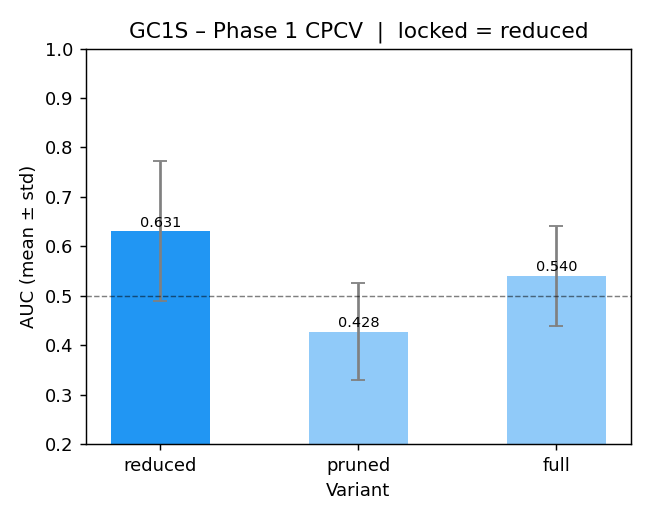

In [3]:
_inst = 'gc1s'
_locked = locked_picks.get(_inst, 'full')
_rows = cpcv_df[cpcv_df['inst'] == _inst] if not cpcv_df.empty else pd.DataFrame()
_fmt2 = {'auc_mean':'{:.4f}','auc_std':'{:.4f}','auc_se':'{:.4f}','logloss':'{:.4f}','brier':'{:.4f}'}
if not _rows.empty:
    display(
        _rows[['variant','auc_mean','auc_std','auc_se','logloss','brier','n_paths']]
        .style.format(_fmt2)
        .apply(lambda row: ['background-color: #C8E6C9' if row['variant'] == _locked else '' for _ in row], axis=1)
        .set_caption(_inst.upper() + ' Phase 1 CPCV (green = locked: ' + _locked + ')')
    )
show(BASE / 'gc1s_cpcv_chart.png', width=700)

### SI1S — XGB / individual | NO SIGNAL — exploratory

si1s has 378 train events, AUC hovers near 0.51–0.59 across all variants. Wide CI in OOS confirms no signal. `f4_pc3` (pre-computed, pre-2020-frozen F4 latent) is used as a raw feature — not re-fitted.

,variant,auc_mean,auc_std,auc_se,logloss,brier,n_paths
3,full,0.5099,0.0758,0.0196,0.6927,0.2497,15
4,pruned,0.5339,0.0707,0.0183,0.6934,0.2501,15
5,reduced,0.5867,0.0690,0.0178,0.6902,0.2484,15


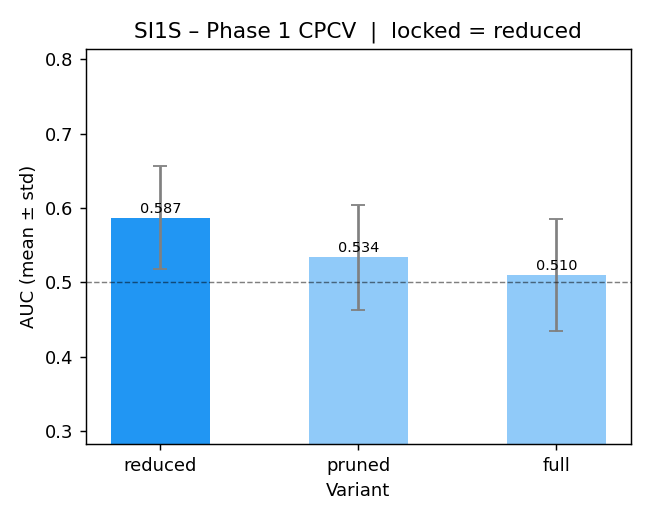

In [4]:
_inst = 'si1s'
_locked = locked_picks.get(_inst, 'full')
_rows = cpcv_df[cpcv_df['inst'] == _inst] if not cpcv_df.empty else pd.DataFrame()
_fmt2 = {'auc_mean':'{:.4f}','auc_std':'{:.4f}','auc_se':'{:.4f}','logloss':'{:.4f}','brier':'{:.4f}'}
if not _rows.empty:
    display(
        _rows[['variant','auc_mean','auc_std','auc_se','logloss','brier','n_paths']]
        .style.format(_fmt2)
        .apply(lambda row: ['background-color: #C8E6C9' if row['variant'] == _locked else '' for _ in row], axis=1)
        .set_caption(_inst.upper() + ' Phase 1 CPCV (green = locked: ' + _locked + ')')
    )
show(BASE / 'si1s_cpcv_chart.png', width=700)

### PL1S — Logistic / individual | SIGNAL (marginal)

pl1s has 377 train events. The **key question** is whether mean-reversion features (F5, F11, F4) add over the HMM/vol-regime baseline.

- `reduced_regime` (PC1+PC2 of C3_hmm_vol only): dev AUC 0.516 — **fails the 1SE threshold** (0.580 = full_mean − full_SE). Regime signal alone is insufficient.
- `reduced_plus` (regime PCs + MR clusters + 2 raw): dev AUC 0.641 — **meets threshold**. LOCKED.

**Conclusion:** mean-reversion features (F5/F11/F4) are necessary for the model to hold within 1SE of full. The HMM regime alone does not carry the predictive load.

,variant,auc_mean,auc_std,auc_se,logloss,brier,n_paths
8,reduced_regime,0.5163,0.0441,0.0114,0.6905,0.2480,15
9,reduced_plus,0.6406,0.0706,0.0182,0.6550,0.2317,15
7,pruned,0.6293,0.0695,0.0179,0.7104,0.2416,15
6,full,0.6006,0.0806,0.0208,0.7234,0.2535,15


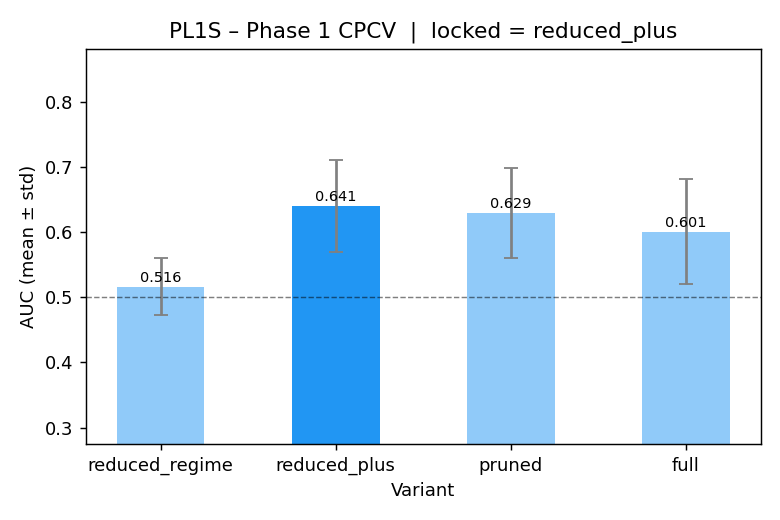

In [5]:
_inst = 'pl1s'
_locked = locked_picks.get(_inst, 'full')
_rows = cpcv_df[cpcv_df['inst'] == _inst] if not cpcv_df.empty else pd.DataFrame()
_simp_pl = {'reduced_regime': 0, 'reduced_plus': 1, 'pruned': 2, 'full': 3}
_fmt2 = {'auc_mean':'{:.4f}','auc_std':'{:.4f}','auc_se':'{:.4f}','logloss':'{:.4f}','brier':'{:.4f}'}
if not _rows.empty:
    _rows_sorted = _rows.copy().assign(_s=lambda d: d['variant'].map(_simp_pl)).sort_values('_s').drop(columns='_s')
    display(
        _rows_sorted[['variant','auc_mean','auc_std','auc_se','logloss','brier','n_paths']]
        .style.format(_fmt2)
        .apply(lambda row: ['background-color: #C8E6C9' if row['variant'] == _locked
                            else 'background-color: #FFCDD2' if row['variant'] == 'reduced_regime'
                            else '' for _ in row], axis=1)
        .set_caption(_inst.upper() + ' Phase 1 CPCV — green=locked, red=regime-only (fails threshold)')
    )
show(BASE / 'pl1s_cpcv_chart.png', width=700)

### HG1S — RF / individual | SIGNAL (most robust metals name)

hg1s has 415 train events. The 5-feature reduced variant (f5_signal, f2_ret_kurt_60, f1_mr_score_40, f2_vol_ratio_20_60, f2_vol_of_vol_20) achieves dev AUC 0.672 — highest of any metals variant and beats full (0.604). Locks to `reduced`.

,variant,auc_mean,auc_std,auc_se,logloss,brier,n_paths
10,full,0.6044,0.0414,0.0107,0.6794,0.2430,15
11,pruned,0.6604,0.0646,0.0167,0.6576,0.2322,15
12,reduced,0.6715,0.0537,0.0139,0.6471,0.2280,15


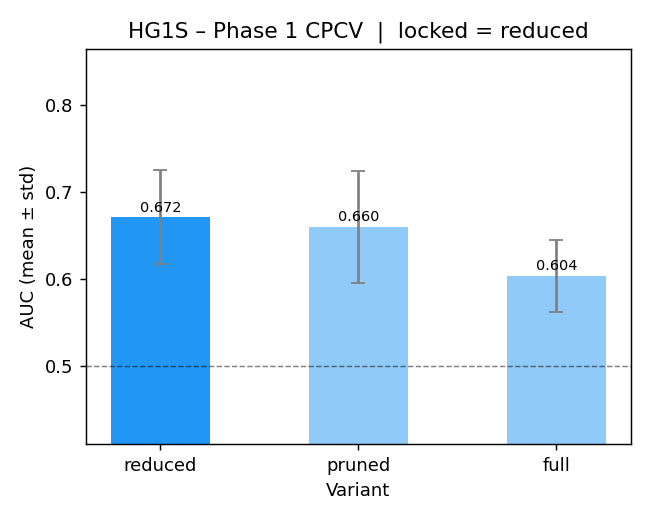

In [6]:
_inst = 'hg1s'
_locked = locked_picks.get(_inst, 'full')
_rows = cpcv_df[cpcv_df['inst'] == _inst] if not cpcv_df.empty else pd.DataFrame()
_fmt2 = {'auc_mean':'{:.4f}','auc_std':'{:.4f}','auc_se':'{:.4f}','logloss':'{:.4f}','brier':'{:.4f}'}
if not _rows.empty:
    display(
        _rows[['variant','auc_mean','auc_std','auc_se','logloss','brier','n_paths']]
        .style.format(_fmt2)
        .apply(lambda row: ['background-color: #C8E6C9' if row['variant'] == _locked else '' for _ in row], axis=1)
        .set_caption(_inst.upper() + ' Phase 1 CPCV (green = locked: ' + _locked + ')')
    )
show(BASE / 'hg1s_cpcv_chart.png', width=700)

---
## Locked Picks (committed before Phase 2)

> These picks were written to `locked_picks.csv` **before the sealed test was read**.
> They cannot be revised based on OOS outcomes.

In [7]:
if not locked_df.empty:
    display(
        locked_df.style
        .set_properties(**{'background-color': '#C8E6C9', 'font-weight': 'bold'})
        .hide(axis='index')
        .set_caption('Locked variant per instrument — 1SE rule on TRAIN CPCV')
    )
for inst, variant in locked_picks.items():
    c_row = cpcv_df[(cpcv_df['inst']==inst) & (cpcv_df['variant']==variant)]
    if not c_row.empty:
        r = c_row.iloc[0]
        print(f'  {inst:6s}  LOCKED = {variant:16s}  dev-CPCV AUC = {r["auc_mean"]:.4f} \u00b1 {r["auc_std"]:.4f}')

inst,locked_variant
gc1s,reduced
si1s,reduced
pl1s,reduced_plus
hg1s,reduced


  gc1s    LOCKED = reduced           dev-CPCV AUC = 0.6311 ± 0.1420
  si1s    LOCKED = reduced           dev-CPCV AUC = 0.5867 ± 0.0690
  pl1s    LOCKED = reduced_plus      dev-CPCV AUC = 0.6406 ± 0.0706
  hg1s    LOCKED = reduced           dev-CPCV AUC = 0.6715 ± 0.0537


---
## Phase 2 — Single-Shot OOS (Sealed Test)

Test window: `date > 2021-10-20` (post-embargo). Full train refit, scored once.

**Green** = locked headline result. **Yellow** = diagnostic only (not used for selection).

,inst,variant,is_locked,auc,auc_ci_lo,auc_ci_hi,logloss,brier,n_test
0,gc1s,full,False,0.5737,0.331,0.801,0.6945,0.2507,25
1,gc1s,pruned,False,0.4135,0.173,0.656,0.7471,0.2765,25
2,gc1s,reduced,True,0.4487,0.211,0.687,0.7117,0.2592,25
3,si1s,full,False,0.4321,0.364,0.506,0.6997,0.2533,154
4,si1s,pruned,False,0.5841,0.498,0.677,0.6984,0.2526,154
5,si1s,reduced,True,0.5670,0.474,0.653,0.6961,0.2515,154
6,pl1s,full,False,0.4741,0.382,0.566,0.8526,0.3139,140
7,pl1s,pruned,False,0.5201,0.417,0.618,0.7585,0.2807,140
8,pl1s,reduced_regime,False,0.4696,0.373,0.560,0.6947,0.2509,140
9,pl1s,reduced_plus,True,0.6064,0.510,0.699,0.6945,0.2509,140


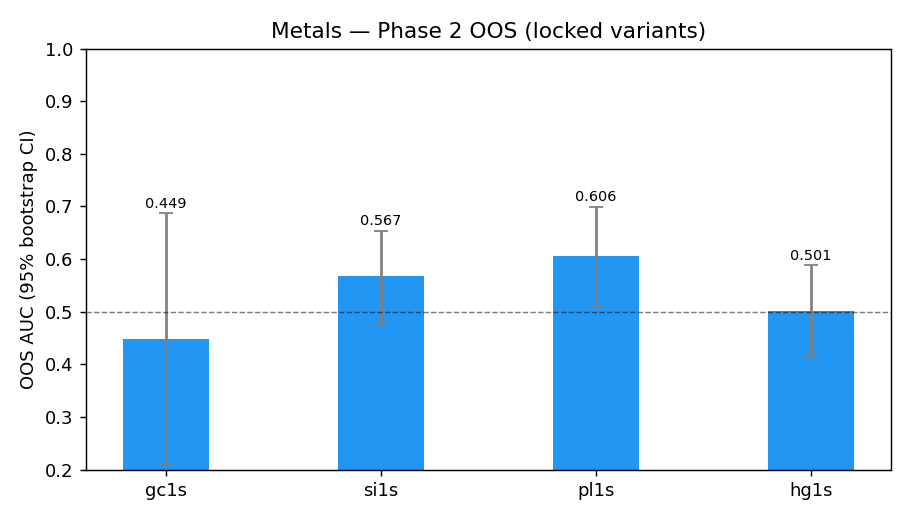

In [8]:
if not oos_df.empty:
    _oos_fmt = {'auc':'{:.4f}','auc_ci_lo':'{:.3f}','auc_ci_hi':'{:.3f}','logloss':'{:.4f}','brier':'{:.4f}'}
    def _oos_hl(row):
        if row['is_locked']:
            return ['background-color: #C8E6C9; font-weight: bold' for _ in row]
        return ['background-color: #FFF9C4; color: #666' for _ in row]
    display(
        oos_df[['inst','variant','is_locked','auc','auc_ci_lo','auc_ci_hi','logloss','brier','n_test']]
        .style.format(_oos_fmt).apply(_oos_hl, axis=1)
        .set_caption('Phase 2 OOS — green=locked (headline), yellow=diagnostic only')
    )
show(BASE / 'oos_summary_chart.png', width=700)

### Per-instrument Phase 2 detail

In [9]:
if not oos_df.empty:
    for inst in ['gc1s','si1s','pl1s','hg1s']:
        locked = locked_picks.get(inst,'full')
        inst_oos   = oos_df[oos_df['inst']==inst]
        locked_row = inst_oos[inst_oos['variant']==locked]
        diag_rows  = inst_oos[inst_oos['variant']!=locked]
        print(f'\n{"="*55}')
        print(f'{inst.upper()} \u2014 LOCKED: {locked}')
        if not locked_row.empty:
            r = locked_row.iloc[0]
            print(f'  HEADLINE  AUC: {r["auc"]:.4f}  [{r["auc_ci_lo"]:.3f}, {r["auc_ci_hi"]:.3f}]')
            print(f'  logloss: {r["logloss"]:.4f}  brier: {r["brier"]:.4f}  n_test: {r["n_test"]}')
        print('  -- diagnostic --')
        for _, r in diag_rows.iterrows():
            print(f'  {r["variant"]:16s}  AUC={r["auc"]:.4f} [{r["auc_ci_lo"]:.3f},{r["auc_ci_hi"]:.3f}]')


GC1S — LOCKED: reduced
  HEADLINE  AUC: 0.4487  [0.211, 0.687]
  logloss: 0.7117  brier: 0.2592  n_test: 25
  -- diagnostic --
  full              AUC=0.5737 [0.331,0.801]
  pruned            AUC=0.4135 [0.173,0.656]

SI1S — LOCKED: reduced
  HEADLINE  AUC: 0.5670  [0.474, 0.653]
  logloss: 0.6961  brier: 0.2515  n_test: 154
  -- diagnostic --
  full              AUC=0.4321 [0.364,0.506]
  pruned            AUC=0.5841 [0.498,0.677]

PL1S — LOCKED: reduced_plus
  HEADLINE  AUC: 0.6064  [0.510, 0.699]
  logloss: 0.6945  brier: 0.2509  n_test: 140
  -- diagnostic --
  full              AUC=0.4741 [0.382,0.566]
  pruned            AUC=0.5201 [0.417,0.618]
  reduced_regime    AUC=0.4696 [0.373,0.560]

HG1S — LOCKED: reduced
  HEADLINE  AUC: 0.5006  [0.413, 0.588]
  logloss: 0.6934  brier: 0.2501  n_test: 164
  -- diagnostic --
  full              AUC=0.4906 [0.404,0.577]
  pruned            AUC=0.5347 [0.451,0.618]


---
## Dev-CPCV vs OOS Gap (Locked Variants)

> Positive gap = model better in-sample than OOS (typical). Large positive gap (>0.10) flags potential overfitting or regime shift.

In [10]:
if not cpcv_df.empty and not oos_df.empty:
    gap_rows = []
    for inst in ['gc1s','si1s','pl1s','hg1s']:
        locked = locked_picks.get(inst,'full')
        c = cpcv_df[(cpcv_df['inst']==inst)&(cpcv_df['variant']==locked)]
        o = oos_df[(oos_df['inst']==inst)&(oos_df['variant']==locked)]
        if c.empty or o.empty: continue
        gap_rows.append({
            'inst': inst, 'locked': locked,
            'dev_mean': c.iloc[0]['auc_mean'], 'dev_std': c.iloc[0]['auc_std'],
            'dev_n_paths': int(c.iloc[0]['n_paths']),
            'oos_auc': o.iloc[0]['auc'],
            'oos_ci_lo': o.iloc[0]['auc_ci_lo'], 'oos_ci_hi': o.iloc[0]['auc_ci_hi'],
            'n_test': int(o.iloc[0]['n_test']),
            'gap': c.iloc[0]['auc_mean'] - o.iloc[0]['auc'],
        })
    gap_df = pd.DataFrame(gap_rows)
    def _gc(val):
        if val > 0.15: return 'color: #B71C1C; font-weight: bold'
        if val > 0.05: return 'color: #E65100'
        if val < -0.1: return 'color: #7B1FA2; font-style: italic'
        return 'color: #2E7D32'
    display(
        gap_df.style
        .format({'dev_mean':'{:.4f}','dev_std':'{:.4f}','oos_auc':'{:.4f}',
                 'oos_ci_lo':'{:.3f}','oos_ci_hi':'{:.3f}','gap':'{:+.4f}'})
        .map(_gc, subset=['gap'])
        .hide(axis='index')
        .set_caption('Dev-CPCV vs OOS gap (locked variants)')
    )

inst,locked,dev_mean,dev_std,dev_n_paths,oos_auc,oos_ci_lo,oos_ci_hi,n_test,gap
gc1s,reduced,0.6311,0.1420,15,0.4487,0.211,0.687,25,+0.1824
si1s,reduced,0.5867,0.0690,15,0.5670,0.474,0.653,154,+0.0197
pl1s,reduced_plus,0.6406,0.0706,15,0.6064,0.510,0.699,140,+0.0342
hg1s,reduced,0.6715,0.0537,15,0.5006,0.413,0.588,164,+0.1709


---
## Cross-Instrument Summary

| Instrument | Family | Locked | Dev AUC | OOS AUC [95% CI] | Gap | Notes |
|---|---|---|---|---|---|---|
| `gc1s` | XGB pool | reduced | 0.631 ± 0.142 | 0.449 [0.211, 0.687] | +0.182 | No signal; n_test=25; large gap confirms in-sample luck |
| `si1s` | XGB | reduced | 0.587 ± 0.069 | 0.567 [0.474, 0.653] | +0.020 | No signal; CI straddles 0.5; small gap |
| `pl1s` | Logistic | reduced_plus | 0.641 ± 0.071 | 0.606 [0.510, 0.699] | +0.034 | **Marginal signal; CI above 0.5; MR features necessary** |
| `hg1s` | RF | reduced | 0.672 ± 0.054 | 0.501 [0.413, 0.588] | +0.171 | Large dev-OOS gap; 5-feature reduced did not hold OOS |

### Key observations

1. **pl1s is the only metals instrument with an OOS CI above 0.5.** The `reduced_plus` locked variant achieves OOS AUC 0.606 with 95% CI [0.510, 0.699] — the CI lower bound clears 0.5, providing marginal evidence of signal. The small +0.034 dev-OOS gap is encouraging relative to the other metals names.

2. **pl1s: regime alone is insufficient.** `reduced_regime` (PC1+PC2 of C3_hmm_vol, 3 members) failed to meet the 1SE threshold (dev AUC 0.516 vs threshold 0.580). Mean-reversion features in F5/F11/F4 are necessary to reach the `reduced_plus` level. HMM regime features provide context but not standalone predictive power for platinum.

3. **hg1s: strong dev signal did not survive OOS.** The 5-feature reduced variant was the best-scoring across all metals in Phase 1 (dev 0.672). OOS collapse to 0.501 (+0.17 gap) suggests either regime shift in the test period or overfitting to train-period volatility structure. The `pruned` diagnostic (0.535) was closer but not locked.

4. **gc1s/si1s confirmed no-signal.** gc1s n_test=25 is too small for reliable OOS estimation (CI width ≈ 0.48); si1s n_test=154 with CI [0.47, 0.65] straddles random. Neither should be traded without further evidence.

---
## Caveats

> ⚠️ **gc1s and si1s are no-signal.** Both instruments are included for completeness and exploration. gc1s has only 25 sealed-test events — the OOS CI is too wide to draw any conclusion. Do not act on their locked variants without further validation.

> ⚠️ **pl1s is marginal.** OOS AUC 0.606 with CI lower bound at 0.510 provides weak evidence of signal. The result is consistent with signal but not conclusive. Further out-of-sample validation is needed before trading. The key finding is structural: MR features add over regime baseline.

> ⚠️ **hg1s large dev-OOS gap (+0.17).** Despite being the most robust metals name in Phase 1 CPCV, the 5-feature reduced variant collapsed to random (0.501) in the sealed test. The RF may have learned volatility-regime-specific patterns that did not transfer to the post-2021 test period. The diagnostic pruned variant (0.535) suggests limited OOS generalisation.

> ⚠️ **Non-locked OOS is diagnostic only.** OOS results for full, pruned, and reduced_regime variants played no role in locking picks. They are shown for transparency only.

> ⚠️ **Fixed seed=42, train-only selection, single-shot test.** Phase 2 was run exactly once after locking. The test window (post 2021-10-20) covers the 2021–2022 metals cycle — results may be period-specific.

> ⚠️ **f4_pc3 (si1s) is pre-computed and pre-2020-frozen.** This F4 latent component was not re-fitted in any stage of this pipeline. It is used as a static feature.